In [15]:
"""
Module Name: examples.ipynb
Author:      Peter Meier
Email:       peter.meier@audiolabs-erlangen.de
Date:        2024-10-01
Version:     0.0.1 
Description: Jupyter Notebook with Example Plots Using Real-Time PLP.
License:     MIT License (https://opensource.org/licenses/MIT)
"""

import librosa
from realtimeplp import RealTimeBeatTracker, BeatAnalyzer
import matplotlib as mpl
import numpy as np
from matplotlib import pyplot as plt

# AUDIO = "assets/audio/basic_groove_8th.wav"
AUDIO = "assets/audio/complex_groove_16th.wav"
SR = librosa.get_samplerate(AUDIO)
HOP = 512
LOW = 60
HIGH = 600
LOOKAHEAD = 0

audio_stream = librosa.stream(
    path=AUDIO, block_length=HOP, frame_length=1, hop_length=1, fill_value=0
)
tracker = RealTimeBeatTracker.from_args(
    N=2 * HOP,
    H=HOP,
    samplerate=SR,
    N_time=6,
    Theta=np.arange(LOW, HIGH + 1, 1),
    lookahead=0,
)
analyzer = BeatAnalyzer(tracker)

# Process every frame of audio in the audio stream of the file
for frame in audio_stream:
    analyzer.process(audio_frame=frame)

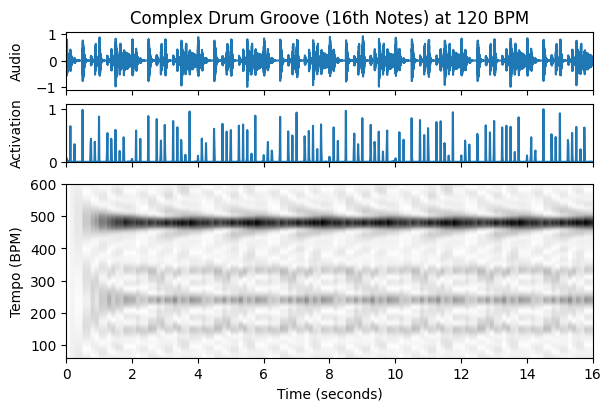

In [16]:
# FIGURE 1
mpl.rcParams["mathtext.fontset"] = "cm"

mosaic = [["A"], ["B"], ["C"]]
fig, axs = plt.subplot_mosaic(
    mosaic=mosaic,
    layout="constrained",
    figsize=(6, 4),
    height_ratios=(1, 1, 3),
    sharex=True,
)

# Waveform
axs["A"].set_title("Complex Drum Groove (16th Notes) at 120 BPM")
waves = np.concatenate(analyzer.audio_frames)
sample_time = np.arange(len(waves)) / analyzer.tracker.activation.samplerate
axs["A"].plot(sample_time, waves)
axs["A"].set_ylim(-1.1, 1.1)
axs["A"].set_xlim(0, max(sample_time))
axs["A"].set_ylabel("Audio")

# Activation
act = np.concatenate(analyzer.activation_frames)
act /= max(act)
axs["B"].plot(analyzer.frame_times, act)
axs["B"].set_xlim(0, max(sample_time))
axs["B"].set_ylim(0, 1.1)
axs["B"].set_ylabel("Activation")

# Tempogram
tempogram = np.abs(np.hstack(analyzer.tempogram_frames))
T = analyzer.frame_times
F = analyzer.tracker.tempogram.Theta
extent = [T[0], T[-1], F[0], F[-1]]
axs["C"].imshow(tempogram, extent=extent, origin="lower", aspect="auto", cmap="Greys")
axs["C"].set_ylabel("Tempo (BPM)")
axs["C"].set_xlabel("Time (seconds)")

# axs["C"].plot(analyzer.frame_times, analyzer.tempo_values, "C3o", markersize=3)
# for i in analyzer.frame_indices[::100]:
#     axs["C"].plot(
#         analyzer.frame_times[i],
#         analyzer.tempo_values[i],
#         marker="o",
#         markeredgecolor="white",
#         markeredgewidth=1.0,
#         markersize=8,
#     )

# # Kernels
# for i in analyzer.frame_indices[::100]:
#     kernel = analyzer.kernels[i]
#     t = kernel.t + i - len(kernel.t) // 2
#     t = t / analyzer.tracker.plp.framerate
#     axs["D"].plot(t, kernel.x)
# axs["D"].set_xlim(0, max(sample_time))
# axs["D"].set_ylabel("Kernels")

# # PLP
# L = len(analyzer.frame_indices) + analyzer.tracker.plp.N
# on_PLP = np.zeros(L)
# for i, kernel in enumerate(analyzer.kernels):
#     t = kernel.t + i
#     on_PLP[t] = on_PLP[t] + kernel.x
# on_PLP = on_PLP[analyzer.tracker.plp.N // 2 : L - analyzer.tracker.plp.N // 2]
# on_PLP_max = np.max(on_PLP)
# if on_PLP_max > 0:
#     on_PLP = on_PLP / on_PLP_max

# n = min(len(analyzer.frame_times), len(on_PLP))
# axs["E"].plot(analyzer.frame_times[:n], on_PLP[:n])
# axs["E"].set_xlim(0, max(sample_time))
# axs["E"].set_xlabel("Time (seconds)")
# axs["E"].set_ylabel("PLP")

# Align y_labels
for ax in axs:
    axs[ax].get_yaxis().set_label_coords(-0.08, 0.5)

plt.savefig("daga2026_complex_groove_16th.png", dpi=300)
plt.show()

In [3]:
%reset -f

In [4]:
"""
Module Name: examples.ipynb
Author:      Peter Meier
Email:       peter.meier@audiolabs-erlangen.de
Date:        2024-10-01
Version:     0.0.1 
Description: Jupyter Notebook with Example Plots Using Real-Time PLP.
License:     MIT License (https://opensource.org/licenses/MIT)
"""

import librosa
from realtimeplp import RealTimeBeatTracker, BeatAnalyzer
import matplotlib as mpl
import numpy as np
from matplotlib import pyplot as plt

# AUDIO = "assets/audio/complex_groove_16th.wav"
AUDIO = "assets/audio/basic_groove_8th.wav"
SR = librosa.get_samplerate(AUDIO)
HOP = 512
LOW = 30
HIGH = 300
LOOKAHEAD = 0
TEMPO_SCALE = 1/2
PHASE_SHIFT = 0.0

audio_stream = librosa.stream(
    path=AUDIO, block_length=HOP, frame_length=1, hop_length=1, fill_value=0
)
tracker = RealTimeBeatTracker.from_args(
    N=2 * HOP,
    H=HOP,
    samplerate=SR,
    N_time=6,
    Theta=np.arange(LOW, HIGH + 1, 1),
    lookahead=0,
    tempo_scale=TEMPO_SCALE,
    phase_shift=PHASE_SHIFT,
)
analyzer = BeatAnalyzer(tracker)

# Process every frame of audio in the audio stream of the file
for frame in audio_stream:
    analyzer.process(audio_frame=frame)

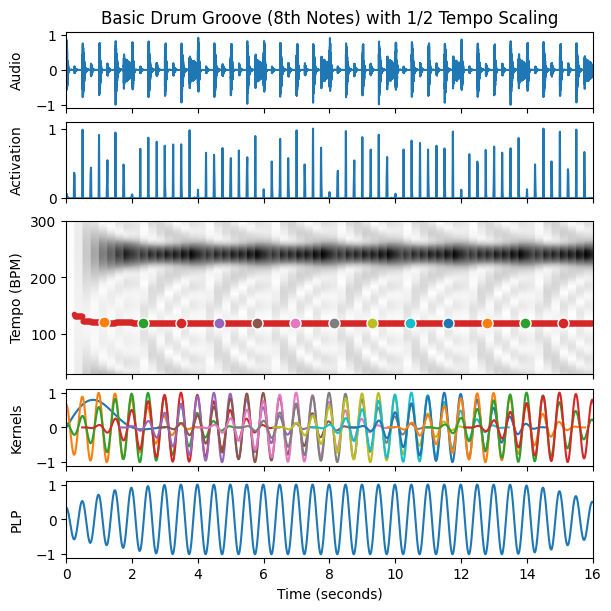

In [5]:
# FIGURE 1
mpl.rcParams["mathtext.fontset"] = "cm"

mosaic = [["A"], ["B"], ["C"], ["D"], ["E"]]
fig, axs = plt.subplot_mosaic(
    mosaic=mosaic,
    layout="constrained",
    figsize=(6, 6),
    height_ratios=(1, 1, 2, 1, 1),
    sharex=True,
)

# Waveform
axs["A"].set_title("Basic Drum Groove (8th Notes) with 1/2 Tempo Scaling")
waves = np.concatenate(analyzer.audio_frames)
sample_time = np.arange(len(waves)) / analyzer.tracker.activation.samplerate
axs["A"].plot(sample_time, waves)
axs["A"].set_ylim(-1.1, 1.1)
axs["A"].set_xlim(0, max(sample_time))
axs["A"].set_ylabel("Audio")

# Activation
act = np.concatenate(analyzer.activation_frames)
act /= max(act)
axs["B"].plot(analyzer.frame_times, act)
axs["B"].set_xlim(0, max(sample_time))
axs["B"].set_ylim(0, 1.1)
axs["B"].set_ylabel("Activation")

# Tempogram
tempogram = np.abs(np.hstack(analyzer.tempogram_frames))
T = analyzer.frame_times
F = analyzer.tracker.tempogram.Theta
extent = [T[0], T[-1], F[0], F[-1]]
axs["C"].imshow(tempogram, extent=extent, origin="lower", aspect="auto", cmap="Greys")
axs["C"].set_ylabel("Tempo (BPM)")
axs["C"].plot(analyzer.frame_times, analyzer.tempo_values, "C3o", markersize=3)
for i in analyzer.frame_indices[::100]:
    axs["C"].plot(
        analyzer.frame_times[i],
        analyzer.tempo_values[i],
        marker="o",
        markeredgecolor="white",
        markeredgewidth=1.0,
        markersize=8,
    )
axs["C"].set_ylim(LOW, HIGH)

# Kernels
for i in analyzer.frame_indices[::100]:
    kernel = analyzer.kernels[i]
    t = kernel.t + i - len(kernel.t) // 2
    t = t / analyzer.tracker.plp.framerate
    axs["D"].plot(t, kernel.x)
axs["D"].set_xlim(0, max(sample_time))
axs["D"].set_ylabel("Kernels")

# PLP
L = len(analyzer.frame_indices) + analyzer.tracker.plp.N
on_PLP = np.zeros(L)
for i, kernel in enumerate(analyzer.kernels):
    t = kernel.t + i
    on_PLP[t] = on_PLP[t] + kernel.x
on_PLP = on_PLP[analyzer.tracker.plp.N // 2 : L - analyzer.tracker.plp.N // 2]
on_PLP = on_PLP / max(on_PLP)
n = min(len(analyzer.frame_times), len(on_PLP))
axs["E"].plot(analyzer.frame_times[:n], on_PLP[:n])
axs["E"].set_xlim(0, max(sample_time))
axs["E"].set_xlabel("Time (seconds)")
axs["E"].set_ylabel("PLP")

# Align y_labels
for ax in axs:
    axs[ax].get_yaxis().set_label_coords(-0.08, 0.5)

plt.savefig("daga2026_basic_groove_8th_1_2_tempo_scaling.png", dpi=300)
plt.show()

In [6]:
%reset -f

In [7]:
"""
Module Name: examples.ipynb
Author:      Peter Meier
Email:       peter.meier@audiolabs-erlangen.de
Date:        2024-10-01
Version:     0.0.1 
Description: Jupyter Notebook with Example Plots Using Real-Time PLP.
License:     MIT License (https://opensource.org/licenses/MIT)
"""

import librosa
from realtimeplp import RealTimeBeatTracker, BeatAnalyzer
import matplotlib as mpl
import numpy as np
from matplotlib import pyplot as plt

# AUDIO = "assets/audio/complex_groove_16th.wav"
AUDIO = "assets/audio/basic_groove_8th.wav"
SR = librosa.get_samplerate(AUDIO)
HOP = 512
LOW = 30
HIGH = 300
LOOKAHEAD = 0
TEMPO_SCALE = 1/3
PHASE_SHIFT = 0.0

audio_stream = librosa.stream(
    path=AUDIO, block_length=HOP, frame_length=1, hop_length=1, fill_value=0
)
tracker = RealTimeBeatTracker.from_args(
    N=2 * HOP,
    H=HOP,
    samplerate=SR,
    N_time=6,
    Theta=np.arange(LOW, HIGH + 1, 1),
    lookahead=0,
    tempo_scale=TEMPO_SCALE,
    phase_shift=PHASE_SHIFT,
)
analyzer = BeatAnalyzer(tracker)

# Process every frame of audio in the audio stream of the file
for frame in audio_stream:
    analyzer.process(audio_frame=frame)

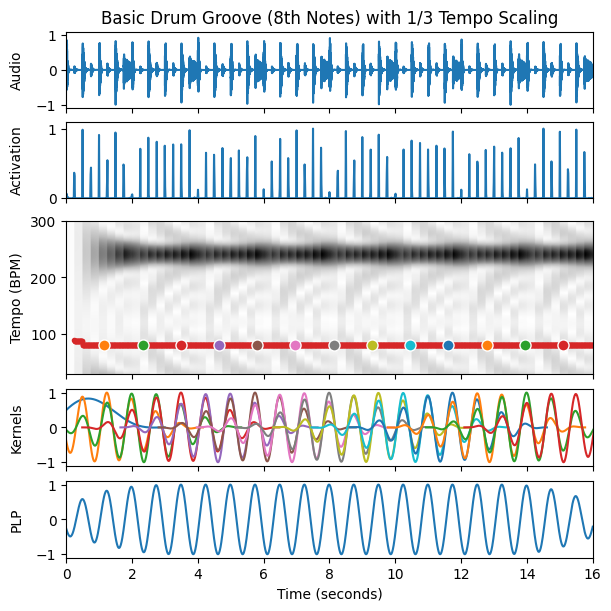

In [8]:
# FIGURE 1
mpl.rcParams["mathtext.fontset"] = "cm"

mosaic = [["A"], ["B"], ["C"], ["D"], ["E"]]
fig, axs = plt.subplot_mosaic(
    mosaic=mosaic,
    layout="constrained",
    figsize=(6, 6),
    height_ratios=(1, 1, 2, 1, 1),
    sharex=True,
)

# Waveform
axs["A"].set_title("Basic Drum Groove (8th Notes) with 1/3 Tempo Scaling")
waves = np.concatenate(analyzer.audio_frames)
sample_time = np.arange(len(waves)) / analyzer.tracker.activation.samplerate
axs["A"].plot(sample_time, waves)
axs["A"].set_ylim(-1.1, 1.1)
axs["A"].set_xlim(0, max(sample_time))
axs["A"].set_ylabel("Audio")

# Activation
act = np.concatenate(analyzer.activation_frames)
act /= max(act)
axs["B"].plot(analyzer.frame_times, act)
axs["B"].set_xlim(0, max(sample_time))
axs["B"].set_ylim(0, 1.1)
axs["B"].set_ylabel("Activation")

# Tempogram
tempogram = np.abs(np.hstack(analyzer.tempogram_frames))
T = analyzer.frame_times
F = analyzer.tracker.tempogram.Theta
extent = [T[0], T[-1], F[0], F[-1]]
axs["C"].imshow(tempogram, extent=extent, origin="lower", aspect="auto", cmap="Greys")
axs["C"].set_ylabel("Tempo (BPM)")
axs["C"].plot(analyzer.frame_times, analyzer.tempo_values, "C3o", markersize=3)
for i in analyzer.frame_indices[::100]:
    axs["C"].plot(
        analyzer.frame_times[i],
        analyzer.tempo_values[i],
        marker="o",
        markeredgecolor="white",
        markeredgewidth=1.0,
        markersize=8,
    )
axs["C"].set_ylim(LOW, HIGH)

# Kernels
for i in analyzer.frame_indices[::100]:
    kernel = analyzer.kernels[i]
    t = kernel.t + i - len(kernel.t) // 2
    t = t / analyzer.tracker.plp.framerate
    axs["D"].plot(t, kernel.x)
axs["D"].set_xlim(0, max(sample_time))
axs["D"].set_ylabel("Kernels")

# PLP
L = len(analyzer.frame_indices) + analyzer.tracker.plp.N
on_PLP = np.zeros(L)
for i, kernel in enumerate(analyzer.kernels):
    t = kernel.t + i
    on_PLP[t] = on_PLP[t] + kernel.x
on_PLP = on_PLP[analyzer.tracker.plp.N // 2 : L - analyzer.tracker.plp.N // 2]
on_PLP = on_PLP / max(on_PLP)
n = min(len(analyzer.frame_times), len(on_PLP))
axs["E"].plot(analyzer.frame_times[:n], on_PLP[:n])
axs["E"].set_xlim(0, max(sample_time))
axs["E"].set_xlabel("Time (seconds)")
axs["E"].set_ylabel("PLP")

# Align y_labels
for ax in axs:
    axs[ax].get_yaxis().set_label_coords(-0.08, 0.5)

plt.savefig("daga2026_basic_groove_8th_1_3_tempo_scaling.png", dpi=300)
plt.show()

In [9]:
%reset -f

In [10]:
"""
Module Name: examples.ipynb
Author:      Peter Meier
Email:       peter.meier@audiolabs-erlangen.de
Date:        2024-10-01
Version:     0.0.1 
Description: Jupyter Notebook with Example Plots Using Real-Time PLP.
License:     MIT License (https://opensource.org/licenses/MIT)
"""

import librosa
from realtimeplp import RealTimeBeatTracker, BeatAnalyzer
import matplotlib as mpl
import numpy as np
from matplotlib import pyplot as plt

# AUDIO = "assets/audio/complex_groove_16th.wav"
AUDIO = "assets/audio/basic_groove_8th.wav"
SR = librosa.get_samplerate(AUDIO)
HOP = 512
LOW = 30
HIGH = 300
LOOKAHEAD = 0
TEMPO_SCALE = 1/2
PHASE_SHIFT = 1/2

audio_stream = librosa.stream(
    path=AUDIO, block_length=HOP, frame_length=1, hop_length=1, fill_value=0
)
tracker = RealTimeBeatTracker.from_args(
    N=2 * HOP,
    H=HOP,
    samplerate=SR,
    N_time=6,
    Theta=np.arange(LOW, HIGH + 1, 1),
    lookahead=0,
    tempo_scale=TEMPO_SCALE,
    phase_shift=PHASE_SHIFT,
)
analyzer = BeatAnalyzer(tracker)

# Process every frame of audio in the audio stream of the file
for frame in audio_stream:
    analyzer.process(audio_frame=frame)

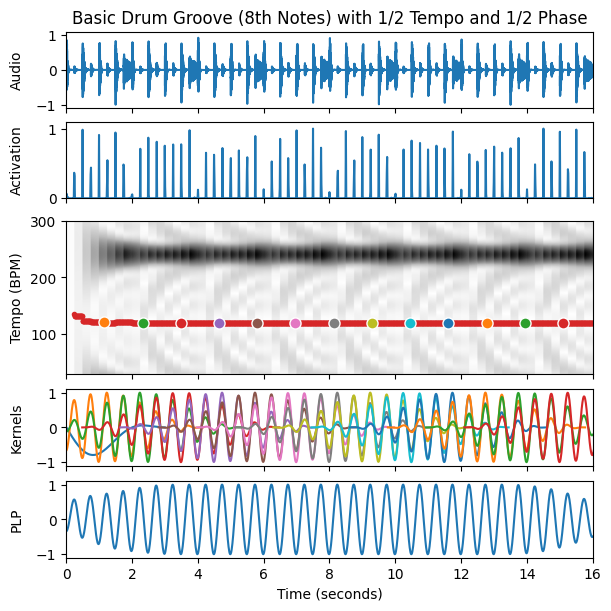

In [11]:
# FIGURE 1
mpl.rcParams["mathtext.fontset"] = "cm"

mosaic = [["A"], ["B"], ["C"], ["D"], ["E"]]
fig, axs = plt.subplot_mosaic(
    mosaic=mosaic,
    layout="constrained",
    figsize=(6, 6),
    height_ratios=(1, 1, 2, 1, 1),
    sharex=True,
)

# Waveform
axs["A"].set_title("Basic Drum Groove (8th Notes) with 1/2 Tempo and 1/2 Phase")
waves = np.concatenate(analyzer.audio_frames)
sample_time = np.arange(len(waves)) / analyzer.tracker.activation.samplerate
axs["A"].plot(sample_time, waves)
axs["A"].set_ylim(-1.1, 1.1)
axs["A"].set_xlim(0, max(sample_time))
axs["A"].set_ylabel("Audio")

# Activation
act = np.concatenate(analyzer.activation_frames)
act /= max(act)
axs["B"].plot(analyzer.frame_times, act)
axs["B"].set_xlim(0, max(sample_time))
axs["B"].set_ylim(0, 1.1)
axs["B"].set_ylabel("Activation")

# Tempogram
tempogram = np.abs(np.hstack(analyzer.tempogram_frames))
T = analyzer.frame_times
F = analyzer.tracker.tempogram.Theta
extent = [T[0], T[-1], F[0], F[-1]]
axs["C"].imshow(tempogram, extent=extent, origin="lower", aspect="auto", cmap="Greys")
axs["C"].set_ylabel("Tempo (BPM)")
axs["C"].plot(analyzer.frame_times, analyzer.tempo_values, "C3o", markersize=3)
for i in analyzer.frame_indices[::100]:
    axs["C"].plot(
        analyzer.frame_times[i],
        analyzer.tempo_values[i],
        marker="o",
        markeredgecolor="white",
        markeredgewidth=1.0,
        markersize=8,
    )
axs["C"].set_ylim(LOW, HIGH)

# Kernels
for i in analyzer.frame_indices[::100]:
    kernel = analyzer.kernels[i]
    t = kernel.t + i - len(kernel.t) // 2
    t = t / analyzer.tracker.plp.framerate
    axs["D"].plot(t, kernel.x)
axs["D"].set_xlim(0, max(sample_time))
axs["D"].set_ylabel("Kernels")

# PLP
L = len(analyzer.frame_indices) + analyzer.tracker.plp.N
on_PLP = np.zeros(L)
for i, kernel in enumerate(analyzer.kernels):
    t = kernel.t + i
    on_PLP[t] = on_PLP[t] + kernel.x
on_PLP = on_PLP[analyzer.tracker.plp.N // 2 : L - analyzer.tracker.plp.N // 2]
on_PLP = on_PLP / max(on_PLP)
n = min(len(analyzer.frame_times), len(on_PLP))
axs["E"].plot(analyzer.frame_times[:n], on_PLP[:n])
axs["E"].set_xlim(0, max(sample_time))
axs["E"].set_xlabel("Time (seconds)")
axs["E"].set_ylabel("PLP")

# Align y_labels
for ax in axs:
    axs[ax].get_yaxis().set_label_coords(-0.08, 0.5)

plt.savefig("daga2026_basic_groove_8th_1_2_tempo_1_2_phase.png", dpi=300)
plt.show()

In [12]:
%reset -f

In [13]:
"""
Module Name: examples.ipynb
Author:      Peter Meier
Email:       peter.meier@audiolabs-erlangen.de
Date:        2024-10-01
Version:     0.0.1 
Description: Jupyter Notebook with Example Plots Using Real-Time PLP.
License:     MIT License (https://opensource.org/licenses/MIT)
"""

import librosa
from realtimeplp import RealTimeBeatTracker, BeatAnalyzer
import matplotlib as mpl
import numpy as np
from matplotlib import pyplot as plt

# AUDIO = "assets/audio/complex_groove_16th.wav"
AUDIO = "assets/audio/basic_groove_8th.wav"
SR = librosa.get_samplerate(AUDIO)
HOP = 512
LOW = 30
HIGH = 300
LOOKAHEAD = 0
TEMPO_SCALE = 1/2
PHASE_SHIFT = 1/4

audio_stream = librosa.stream(
    path=AUDIO, block_length=HOP, frame_length=1, hop_length=1, fill_value=0
)
tracker = RealTimeBeatTracker.from_args(
    N=2 * HOP,
    H=HOP,
    samplerate=SR,
    N_time=6,
    Theta=np.arange(LOW, HIGH + 1, 1),
    lookahead=0,
    tempo_scale=TEMPO_SCALE,
    phase_shift=PHASE_SHIFT,
)
analyzer = BeatAnalyzer(tracker)

# Process every frame of audio in the audio stream of the file
for frame in audio_stream:
    analyzer.process(audio_frame=frame)

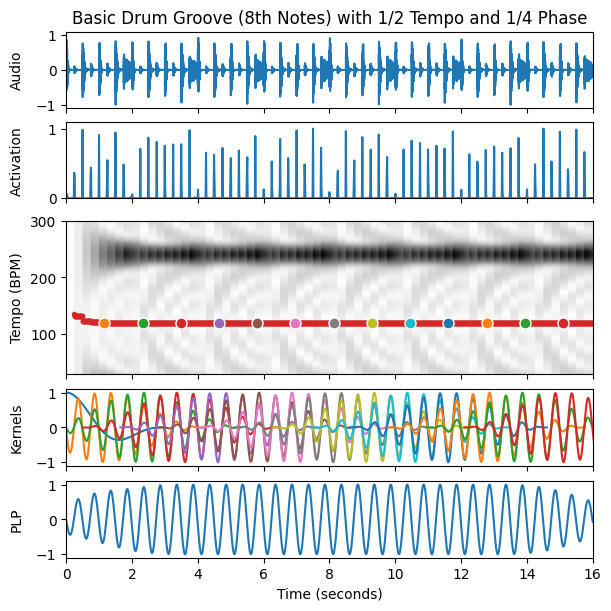

In [14]:
# FIGURE 1
mpl.rcParams["mathtext.fontset"] = "cm"

mosaic = [["A"], ["B"], ["C"], ["D"], ["E"]]
fig, axs = plt.subplot_mosaic(
    mosaic=mosaic,
    layout="constrained",
    figsize=(6, 6),
    height_ratios=(1, 1, 2, 1, 1),
    sharex=True,
)

# Waveform
axs["A"].set_title("Basic Drum Groove (8th Notes) with 1/2 Tempo and 1/4 Phase")
waves = np.concatenate(analyzer.audio_frames)
sample_time = np.arange(len(waves)) / analyzer.tracker.activation.samplerate
axs["A"].plot(sample_time, waves)
axs["A"].set_ylim(-1.1, 1.1)
axs["A"].set_xlim(0, max(sample_time))
axs["A"].set_ylabel("Audio")

# Activation
act = np.concatenate(analyzer.activation_frames)
act /= max(act)
axs["B"].plot(analyzer.frame_times, act)
axs["B"].set_xlim(0, max(sample_time))
axs["B"].set_ylim(0, 1.1)
axs["B"].set_ylabel("Activation")

# Tempogram
tempogram = np.abs(np.hstack(analyzer.tempogram_frames))
T = analyzer.frame_times
F = analyzer.tracker.tempogram.Theta
extent = [T[0], T[-1], F[0], F[-1]]
axs["C"].imshow(tempogram, extent=extent, origin="lower", aspect="auto", cmap="Greys")
axs["C"].set_ylabel("Tempo (BPM)")
axs["C"].plot(analyzer.frame_times, analyzer.tempo_values, "C3o", markersize=3)
for i in analyzer.frame_indices[::100]:
    axs["C"].plot(
        analyzer.frame_times[i],
        analyzer.tempo_values[i],
        marker="o",
        markeredgecolor="white",
        markeredgewidth=1.0,
        markersize=8,
    )
axs["C"].set_ylim(LOW, HIGH)

# Kernels
for i in analyzer.frame_indices[::100]:
    kernel = analyzer.kernels[i]
    t = kernel.t + i - len(kernel.t) // 2
    t = t / analyzer.tracker.plp.framerate
    axs["D"].plot(t, kernel.x)
axs["D"].set_xlim(0, max(sample_time))
axs["D"].set_ylabel("Kernels")

# PLP
L = len(analyzer.frame_indices) + analyzer.tracker.plp.N
on_PLP = np.zeros(L)
for i, kernel in enumerate(analyzer.kernels):
    t = kernel.t + i
    on_PLP[t] = on_PLP[t] + kernel.x
on_PLP = on_PLP[analyzer.tracker.plp.N // 2 : L - analyzer.tracker.plp.N // 2]
on_PLP = on_PLP / max(on_PLP)
n = min(len(analyzer.frame_times), len(on_PLP))
axs["E"].plot(analyzer.frame_times[:n], on_PLP[:n])
axs["E"].set_xlim(0, max(sample_time))
axs["E"].set_xlabel("Time (seconds)")
axs["E"].set_ylabel("PLP")

# Align y_labels
for ax in axs:
    axs[ax].get_yaxis().set_label_coords(-0.08, 0.5)

plt.savefig("daga2026_basic_groove_8th_1_2_tempo_1_4_phase.png", dpi=300)
plt.show()